In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import glob
import numpy as np
from glob import glob
from itertools import compress
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates
import pandas as pd

In [2]:
files_in = glob("/data/project/ARM_Summer_School_2026/data/modeling/dpscream/scream_dpxx_LASSO_SGP_*.fullfield.AVERAGE.nhours_x1.*.nc")
ds_dp_scream = xr.open_mfdataset(files_in, combine='nested', concat_dim = 'date')
ds_dp_scream = ds_dp_scream.assign_coords(time=ds_dp_scream.time - pd.Timedelta(hours=6))

ERROR 1: PROJ: proj_create_from_database: Open of /opt/conda/share/proj failed


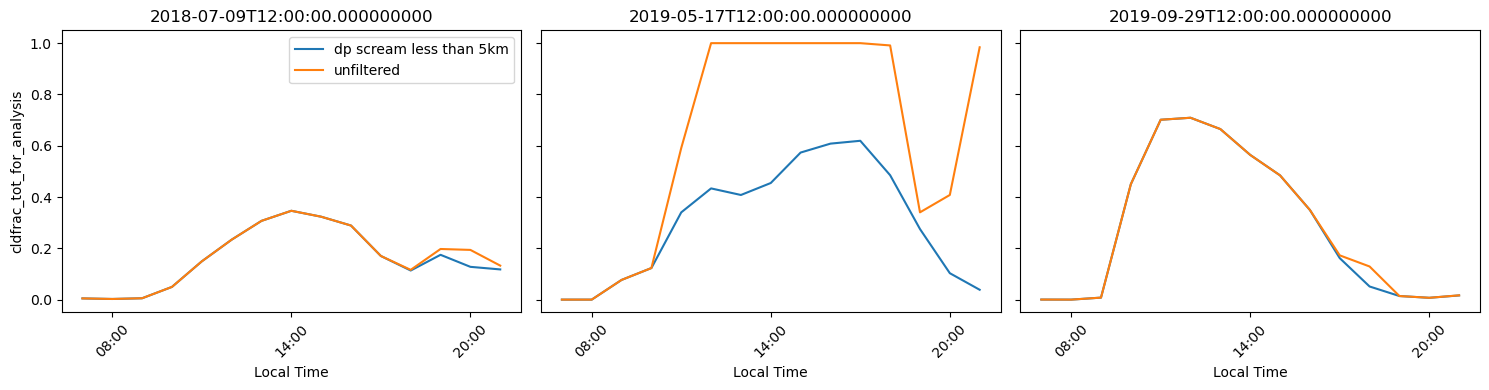

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, ax in enumerate(axes):
  ds_dp_scream['cldfrac_tot_for_analysis'].where(ds_dp_scream['z_mid'] < 5000).max(dim='lev').mean('ncol').isel(date=i).plot(
      ax=ax, label="dp scream less than 5km"
  )
  ds_dp_scream['cldfrac_tot_for_analysis'].max(dim='lev').mean('ncol').isel(date=i).plot(
      ax=ax, label="unfiltered"
    )
  
  date_label =  np.unique(ds_dp_scream.isel(date= i).time_bnds.values)[0] 
  ax.set_title(date_label)

  ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
  ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
  plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
  ax.set_xlabel("Local Time")
  if i > 0:
      ax.set_ylabel("")

axes[0].legend()
plt.tight_layout()
plt.show()

In [ ]:
# x = np.unique(ds_dp_scream.lon.values)   # 10 values: 2500, 7500, ..., 47500 m
# y = np.unique(ds_dp_scream.lat.values)   # same

# cf_colmax = ds_dp_scream['cldfrac_tot_for_analysis'].max(dim='lev')   # (time, ncol)

# cf_scream = xr.DataArray(
#   cf_colmax.values.reshape(ds_dp_scream.sizes['time'], len(y), len(x)),
#   dims=['time', 'y', 'x'],
#   coords={
#       'time': ds_dp_scream.time,
#       'y': y,
#       'x': x,
#   },
#   attrs={'units': '1', 'long_name': 'Column-max total cloud fraction'},
# )

# cf_scream.isel(time = 8).plot()